In [1]:
import argparse
import csv
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import random
import scanpy as sc
from torch.utils.data import DataLoader
from model.dataset import BagsDataset, custom_collate_fn
from model.model import MIL

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def load_all_genes(reference_gene_file):
    all_genes = []
    with open(reference_gene_file, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            all_genes.append(row['Gene'])
    return all_genes

all_genes = load_all_genes('data/human.csv')

In [4]:
model_path = 'finalize_model/tcell/model_epoch_9.pth'
all_genes_df = pd.read_csv('data/human_filtered.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()

# Initialize the model
model = MIL(all_genes).to(device)

In [5]:
model.load_state_dict(torch.load(model_path, map_location=device))


<All keys matched successfully>

In [6]:
model.state_dict()

OrderedDict([('alpha', tensor(4.0484)),
             ('beta', tensor(-4.3619)),
             ('distance.a', tensor(-0.6811)),
             ('gene_expression.b', tensor(-0.9713)),
             ('immunogenicity.ig',
              tensor([-1.3999e-42, -3.5400e+00, -1.3999e-42,  ..., -1.2754e+01,
                      -1.2791e+01, -1.3999e-42]))])

In [7]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from model.dataset import BagsDataset, custom_collate_fn


In [8]:

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [9]:

# Load the list of all genes used during training
all_genes_df = pd.read_csv('data/human_filtered.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()


In [114]:

# Load the prediction dataset
adata = sc.read('/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/VisiumHD/processed/Lung_Cancer_HD_Only_Experiment1T_cell.h5ad')
prediction_dataset = BagsDataset(adata, immune_cell='tcell', radius=50, n_genes=500, resolution='high',k=2)
prediction_dataloader = torch.utils.data.DataLoader(prediction_dataset, batch_size=1, collate_fn=custom_collate_fn)
adata.obs['T_pred'] = np.nan


Immune cell: T
[2 1 0]
Tumor cells shape after filtering: (101370, 18085)
Selecting top 500 genes based on mean expression


/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessed data: (153848, 557)


Creating Bags with radius 50: 100%|███████████████████████| 153848/153848 [01:34<00:00, 1620.05it/s]


Total batches created: 928


In [115]:
import torch

def predict(model, prediction_dataloader, adata, device='cuda'):
    """
    Perform prediction/inference using the given model and dataloader, and store
    the predictions in `adata.obs`.

    Args:
        model (nn.Module): The trained model to use for inference.
        prediction_dataloader (DataLoader): Dataloader that yields batches of
            (distances_list, gene_expressions_list, labels_list, core_idxs_list,
             gene_names_list, cell_ids_list).
        adata (AnnData): The annotated data object where predictions will be stored.
        device (str, optional): The device to run predictions on. Default is 'cuda'.

    Returns:
        None. The predictions are stored in `adata.obs` under the column 'T_pred'.
    """

    model.eval()
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"Using device for prediction: {device}")

    with torch.no_grad():
        for batch_data in prediction_dataloader:
            # Unpack the batch. Each batch contains lists of tensors/objects:
            # distances_list, gene_expressions_list, labels_list, core_idxs_list,
            # gene_names_list, cell_ids_list.
            (
                distances_list, 
                gene_expressions_list, 
                labels_list,        # Might not be needed for inference, but still returned.
                core_idxs_list, 
                gene_names_list, 
                cell_ids_list
            ) = batch_data

            # Move data to the appropriate device (GPU or CPU).
            distances_list = [distances.to(device) for distances in distances_list]
            gene_expressions_list = [gene_exp.to(device) for gene_exp in gene_expressions_list]

            # Forward pass through the model.
            outputs = model(distances_list, gene_expressions_list, gene_names_list)

            # If the model returns None (e.g., due to skipping certain batches), skip them.
            if outputs is None:
                continue

           
            for output, cell_id in zip(outputs, cell_ids_list):
                # Detach from GPU and convert to Python float.
                prediction = output.cpu().item()
                # Store the prediction in adata.obs using the matching cell_id.
                adata.obs.loc[cell_id, 'T_pred'] = prediction
                print(f"cell_id={cell_id}, prediction={prediction}")


In [116]:
predict(model, prediction_dataloader, adata)

Using device for prediction: cpu
cell_id=s_008um_00086_00091-1, prediction=0.4574660360813141
cell_id=s_008um_00203_00444-1, prediction=0.6460930109024048
cell_id=s_008um_00117_00728-1, prediction=0.6408920884132385
cell_id=s_008um_00122_00127-1, prediction=0.5824661254882812
cell_id=s_008um_00498_00411-1, prediction=0.6439170837402344
cell_id=s_008um_00647_00297-1, prediction=0.6359160542488098
cell_id=s_008um_00101_00721-1, prediction=0.5723155736923218
cell_id=s_008um_00808_00238-1, prediction=0.5629292726516724
cell_id=s_008um_00118_00727-1, prediction=0.6466323733329773
cell_id=s_008um_00396_00379-1, prediction=0.5861299633979797
cell_id=s_008um_00638_00064-1, prediction=0.5866600275039673
cell_id=s_008um_00177_00121-1, prediction=0.5731614828109741
cell_id=s_008um_00325_00685-1, prediction=0.5992591977119446
cell_id=s_008um_00647_00209-1, prediction=0.6283525228500366
cell_id=s_008um_00190_00735-1, prediction=0.6934115886688232
cell_id=s_008um_00326_00446-1, prediction=0.66663253

In [117]:
adata.obs

,in_tissue,array_row,array_col,X,Y,n_genes,tumor_gene_signature,stromal_immune_gene_signature,t_gene_signature,b_gene_signature,...,endothelial_gene_signature,fibroblast_gene_signature,leiden,leiden_sub,T,B,Macrophage,Endothelial,cell_type,T_pred
s_008um_00086_00091-1,1,86,91,728,688,240,3.649441,44.473354,0.0,0.000000,...,0.000000,3.649441,3,3.1,1,0,0,0,2,0.457466
s_008um_00123_00164-1,1,123,164,1312,984,288,6.869911,17.174776,0.0,0.000000,...,3.434955,4.111858,1,1,0,0,0,0,1,0.633178
s_008um_00504_00410-1,1,504,410,3280,4032,327,0.000000,66.019638,0.0,6.807041,...,7.483420,4.764556,3,3.1,1,0,0,0,2,NaN
s_008um_00013_00648-1,1,13,648,5184,104,275,11.581820,24.508215,0.0,0.000000,...,0.000000,0.000000,0,0,0,0,0,0,1,0.611822
s_008um_00161_00253-1,1,161,253,2024,1288,361,7.095243,32.688744,0.0,3.211228,...,0.000000,3.884016,1,1,0,0,0,0,1,0.588026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00631_00323-1,1,631,323,2584,5048,246,4.208048,29.316210,0.0,3.529666,...,3.529666,4.893729,0,0,0,0,0,0,1,NaN
s_008um_00197_00639-1,1,197,639,5112,1576,479,7.032415,31.786137,0.0,3.509002,...,0.000000,2.845343,2,2,0,0,0,0,1,NaN
s_008um_00653_00166-1,1,653,166,1328,5224,221,0.000000,29.759552,0.0,3.634961,...,3.634961,3.634961,0,0,0,0,0,0,1,NaN
s_008um_00353_00477-1,1,353,477,3816,2824,486,5.709099,23.330076,0.0,0.000000,...,0.000000,0.000000,2,2,0,0,0,0,1,NaN


In [118]:
mask = ~adata.obs['T_pred'].isna()
adata = adata[mask].copy()

In [119]:
adata.obs['T'].value_counts()   

T
1    928
0    928
Name: count, dtype: int64

In [120]:
#auroc 
from sklearn.metrics import roc_auc_score
roc_auc_score(adata.obs['T'], adata.obs['T_pred'])


0.4830146635329964

In [121]:
#binarize the prediction,percentile is 0.5 as threshold, <0.5 as 0,>0.5 as 1
threshold_val = np.percentile(adata.obs['T_pred'], 50)
adata.obs['T_pred_binary'] = (adata.obs['T_pred'] > threshold_val).astype(int)


In [122]:
adata.obs

,in_tissue,array_row,array_col,X,Y,n_genes,tumor_gene_signature,stromal_immune_gene_signature,t_gene_signature,b_gene_signature,...,fibroblast_gene_signature,leiden,leiden_sub,T,B,Macrophage,Endothelial,cell_type,T_pred,T_pred_binary
s_008um_00086_00091-1,1,86,91,728,688,240,3.649441,44.473354,0.000000,0.000000,...,3.649441,3,3.1,1,0,0,0,2,0.457466,0
s_008um_00123_00164-1,1,123,164,1312,984,288,6.869911,17.174776,0.000000,0.000000,...,4.111858,1,1,0,0,0,0,1,0.633178,1
s_008um_00013_00648-1,1,13,648,5184,104,275,11.581820,24.508215,0.000000,0.000000,...,0.000000,0,0,0,0,0,0,1,0.611822,1
s_008um_00161_00253-1,1,161,253,2024,1288,361,7.095243,32.688744,0.000000,3.211228,...,3.884016,1,1,0,0,0,0,1,0.588026,0
s_008um_00401_00407-1,1,401,407,3256,3208,386,3.168805,31.331490,0.000000,7.407785,...,0.000000,2,2,0,0,0,0,1,0.589960,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00386_00635-1,1,386,635,5080,3088,467,5.956838,148.521072,3.645801,0.000000,...,7.705278,3,3.4,1,0,0,0,2,0.598082,0
s_008um_00363_00063-1,1,363,63,504,2904,234,3.671585,114.351608,3.671585,0.000000,...,3.671585,3,3.1,1,0,0,0,2,0.526014,0
s_008um_00507_00402-1,1,507,402,3216,4056,339,0.000000,107.716385,0.000000,5.078758,...,3.992524,3,3.4,1,0,0,0,2,0.564857,0
s_008um_00180_00631-1,1,180,631,5048,1440,232,0.000000,105.633957,0.000000,4.791831,...,4.791831,3,3.4,1,0,0,0,2,0.611053,1


In [123]:
roc_auc_score(adata.obs['T'], adata.obs['T_pred_binary'])

0.5021551724137931

In [124]:
!pwd

/project/DPDS/Wang_lab/s439765/spatial_tcr/MIL_TCR


In [125]:
adata.write_h5ad('./validation/diff_gene/Lung_Cancer_HD_Only_Experiment1T_cell.h5ad')

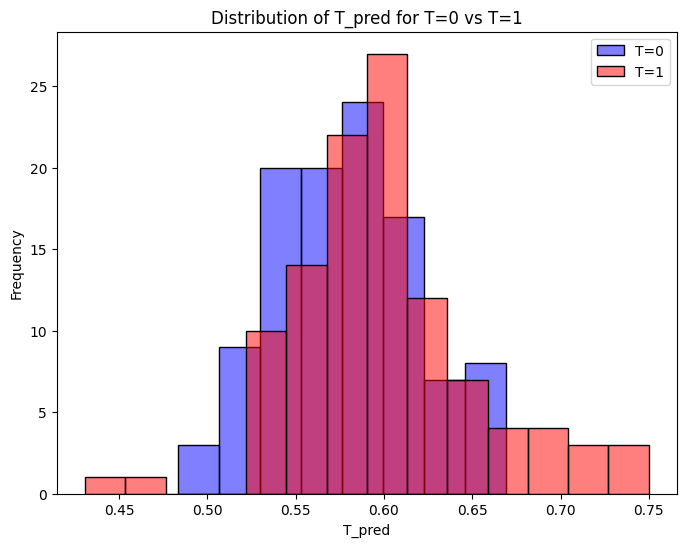

In [113]:
df = adata.obs.dropna(subset=['T_pred', 'T']).copy()
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.histplot(df.loc[df['T'] == 0, 'T_pred'], 
             color='blue', alpha=0.5, label='T=0')
sns.histplot(df.loc[df['T'] == 1, 'T_pred'], 
             color='red', alpha=0.5, label='T=1')
plt.legend()
plt.xlabel('T_pred')
plt.ylabel('Frequency')
plt.title('Distribution of T_pred for T=0 vs T=1')
plt.show()

最优阈值: 0.571
Youden's J statistic: 0.194


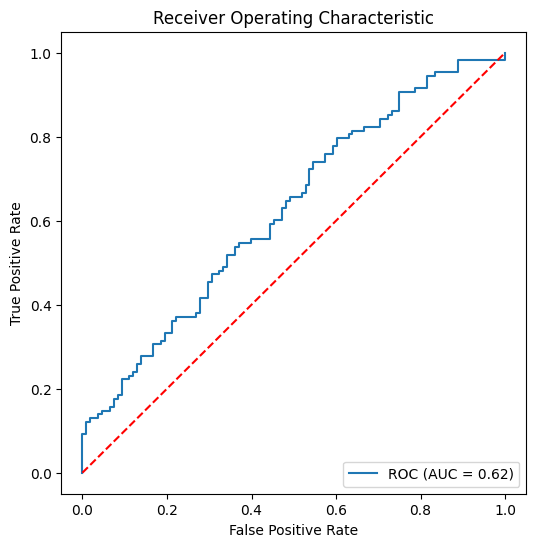

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

df = adata.obs.dropna(subset=['T_pred', 'T']).copy()
df['T'] = df['T'].astype(int)

y_true = df['T']
y_score = df['T_pred']

# 计算 ROC 曲线各点以及 AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Youden’s J = TPR - FPR，取最大时对应的阈值
youdenJ = tpr - fpr
ix = np.argmax(youdenJ)
best_thresh = thresholds[ix]

print(f'最优阈值: {best_thresh:.3f}')
print(f'Youden\'s J statistic: {youdenJ[ix]:.3f}')

# 绘制 ROC 曲线
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


In [59]:
best_thresh

0.5516906976699829

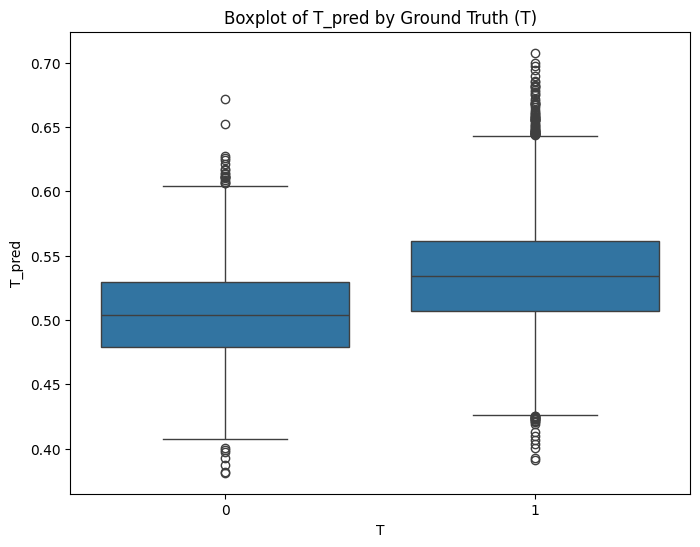

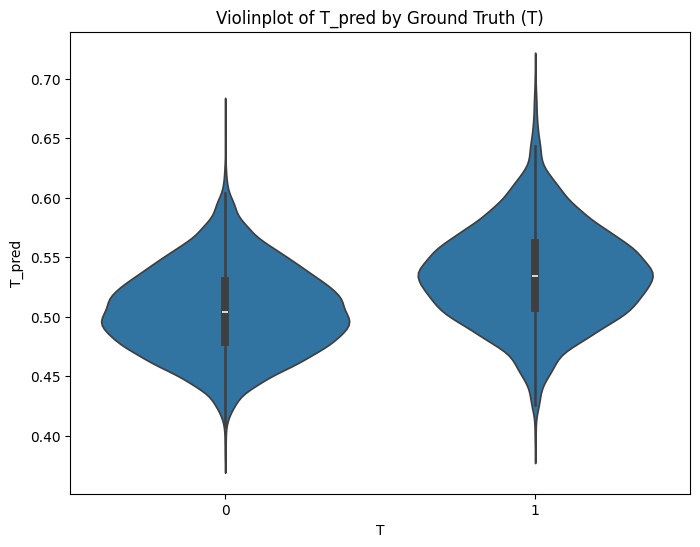

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='T', y='T_pred')
plt.title('Boxplot of T_pred by Ground Truth (T)')
plt.show()

# 或者小提琴图
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='T', y='T_pred')
plt.title('Violinplot of T_pred by Ground Truth (T)')
plt.show()